# 02 — Analyse exploratoire des données — EDA

## Projet : Smart City Energy Forecasting — Tetouan

**Correspondance méthodologique :** Ce notebook couvre l'étape **9 (Analyse exploratoire des données)** de la méthodologie KDD.


## Importation des bibliothèques et configuration visuelle

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

# Style des graphiques
plt.rcParams.update({
    "figure.figsize": (14, 5),
    "figure.dpi": 100,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})
sns.set_style("whitegrid")

# Résolution du chemin projet
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.data_loader import load_tetouan_data
from src.preprocessing import resample_hourly, detect_rolling_outliers

print("✅ Bibliothèques importées avec succès.")


✅ Bibliothèques importées avec succès.


## Chargement des données auditées

Nous chargeons les données brutes via `src.data_loader` qui s'assure du renommage des colonnes et du parsing des dates, ou bien directement le fichier audité généré à l'étape précédente. Ici nous chargeons le fichier audité.

In [2]:
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "tetouan_audited_10min.csv"

# Chargement des données préparées dans le notebook 01
df = pd.read_csv(DATA_PATH, index_col="datetime", parse_dates=True)

print(f"✅ Dataset chargé avec succès.")
print(f"   Dimensions : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"   Index : {df.index.name} ({df.index.dtype})")


✅ Dataset chargé avec succès.
   Dimensions : 52,416 lignes × 10 colonnes
   Index : datetime (datetime64[ns])


## 9.1 Dimensions du dataset

**Pourquoi :** vérifier le volume de données et la faisabilité des modèles.

**Interprétation :** le fichier contient 52,416 observations, ce qui est suffisant pour des modèles temporels et ML.

**Impact :** les modèles peuvent être entraînés sur un historique significatif ; le GRU est possible après resampling ou optimisation.

In [3]:
print("Dimensions :", df.shape)
df.info()

Dimensions : (52416, 10)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 52416 entries, 2017-01-01 00:00:00 to 2017-12-30 23:50:00
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   temperature            52416 non-null  float64
 1   humidity               52416 non-null  float64
 2   wind_speed             52416 non-null  float64
 3   general_diffuse_flows  52416 non-null  float64
 4   diffuse_flows          52416 non-null  float64
 5   zone1_power            52416 non-null  float64
 6   zone2_power            52416 non-null  float64
 7   zone3_power            52416 non-null  float64
 8   target                 52416 non-null  float64
 9   total_load             52416 non-null  float64
dtypes: float64(10)
memory usage: 4.4 MB


## 9.2 Types des variables

**Pourquoi :** détecter les colonnes mal typées.

**Interprétation :** `DateTime` doit être convertie en datetime ; les autres colonnes sont numériques.

**Impact :** sans conversion correcte, le resampling, les lags et les features calendaires ne fonctionneront pas.

In [4]:
from IPython.display import display

display(df.dtypes)

temperature              float64
humidity                 float64
wind_speed               float64
general_diffuse_flows    float64
diffuse_flows            float64
zone1_power              float64
zone2_power              float64
zone3_power              float64
target                   float64
total_load               float64
dtype: object

## 9.3 Valeurs manquantes

**Pourquoi :** identifier les trous dans les mesures.

**Interprétation :** dans le fichier fourni, aucune valeur manquante n'a été détectée.

**Impact :** le pipeline doit quand même contenir une fonction d'imputation pour être robuste.

In [5]:
display(df.isna().sum())

temperature              0
humidity                 0
wind_speed               0
general_diffuse_flows    0
diffuse_flows            0
zone1_power              0
zone2_power              0
zone3_power              0
target                   0
total_load               0
dtype: int64

## 9.4 Doublons temporels

**Pourquoi :** une même date ne doit pas apparaître plusieurs fois pour la même série.

**Interprétation :** aucun doublon temporel n'a été détecté.

**Impact :** l'index temporel peut être construit directement.

In [6]:
print("Nombre de doublons temporels :", df.index.duplicated().sum())

Nombre de doublons temporels : 0


## 9.5 Régularité de `DateTime`

**Pourquoi :** les modèles de séries temporelles supposent souvent un pas régulier.

**Interprétation :** la fréquence inférée est de 10 minutes.

**Impact :** le dataset est compatible avec SARIMA, Prophet, XGBoost, Random Forest et GRU.

In [7]:
print("Fréquence inférée :", pd.infer_freq(df.index))

Fréquence inférée : 10min


## 9.6 Statistiques descriptives

**Pourquoi :** comprendre les ordres de grandeur, la dispersion et les valeurs extrêmes.

**Interprétation :** comparer moyenne, médiane, min, max, écart-type et percentiles des trois zones.

**Impact :** les fortes dispersions ou valeurs extrêmes influenceront RMSE et robustesse.

In [8]:
display(df[["zone1_power", "zone2_power", "zone3_power"]].describe().T)

,count,mean,std,min,25%,50%,75%,max
zone1_power,52416.00,32344.97,7130.56,13895.70,26310.67,32265.92,37309.02,52204.40
zone2_power,52416.00,21042.51,5201.47,8560.08,16980.77,20823.17,24713.72,37408.86
zone3_power,52416.00,17835.41,6622.17,5935.17,13129.33,16415.12,21624.10,47598.33


## 9.7 Évolution temporelle de Zone 1, Zone 2 et Zone 3

**Pourquoi :** visualiser les cycles, tendances et pics.

**Interprétation :** les trois zones peuvent présenter des niveaux et saisonnalités différents.

**Impact :** si les zones ont des dynamiques différentes, il vaut mieux garder `zone1_power` comme cible principale et utiliser les autres en robustesse.

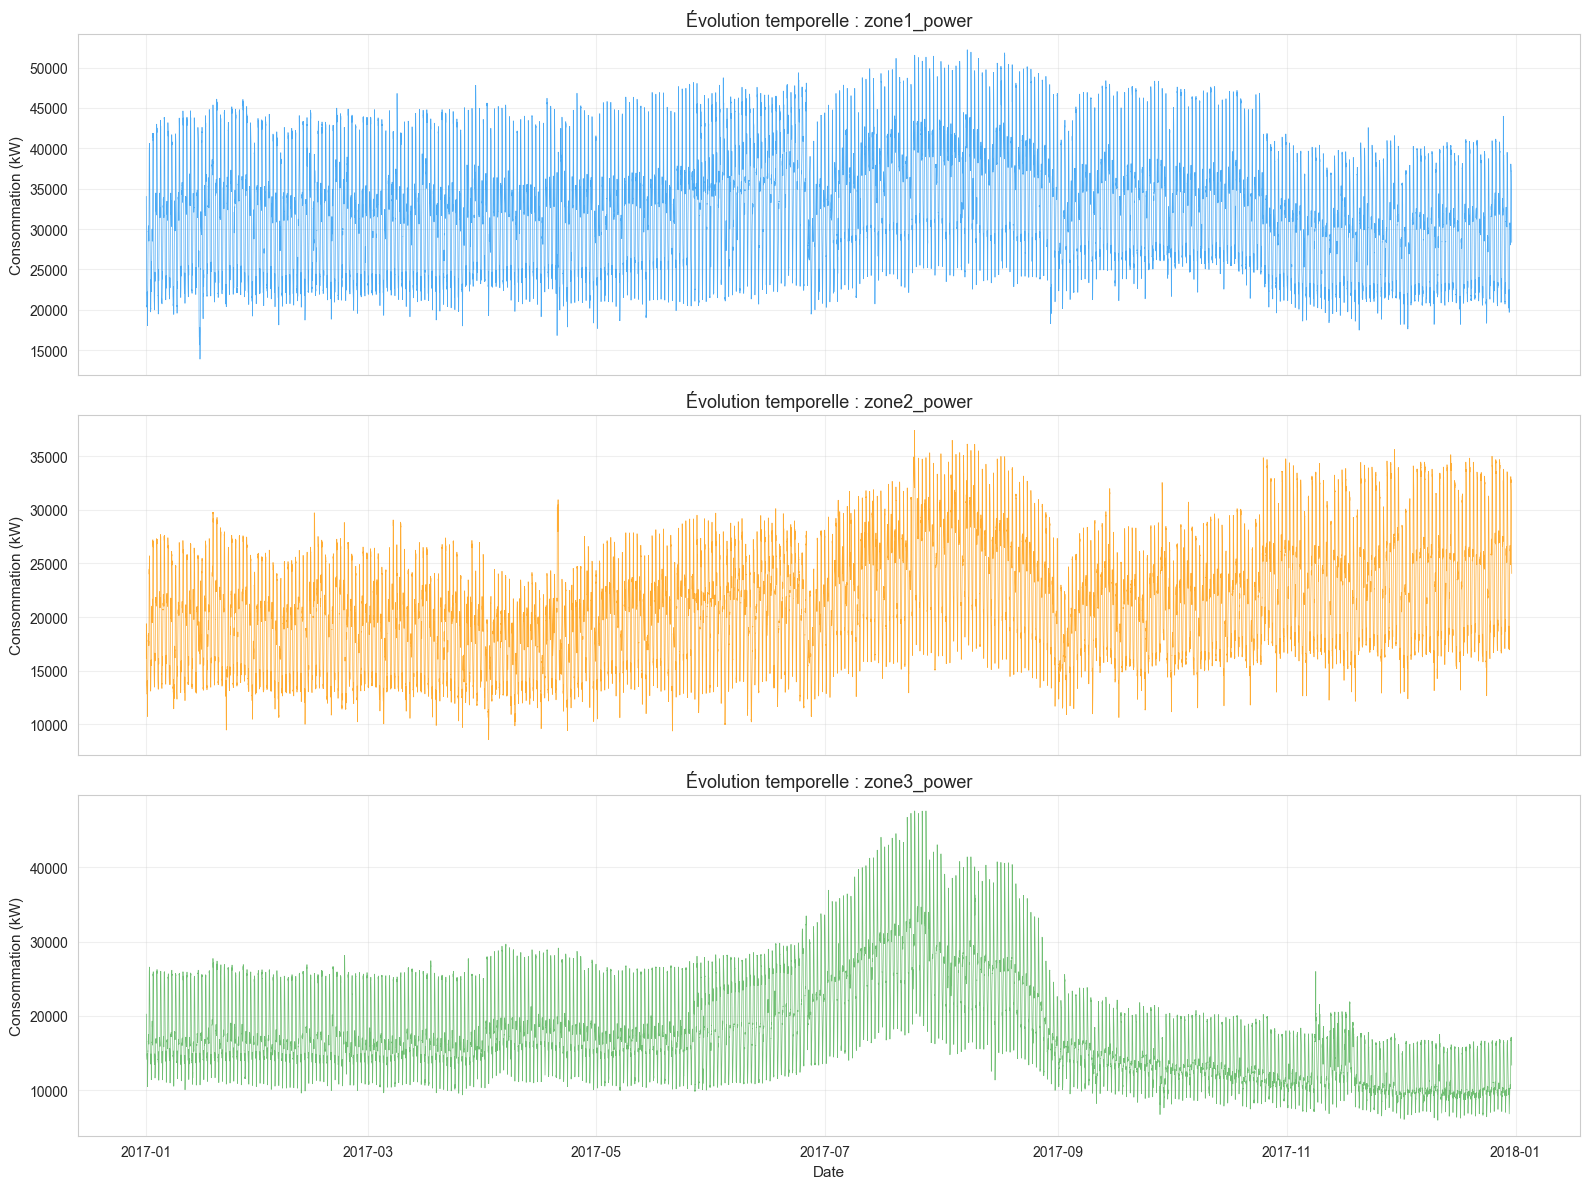

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
zones = ["zone1_power", "zone2_power", "zone3_power"]
colors = ["#2196F3", "#FF9800", "#4CAF50"]

for ax, zone, color in zip(axes, zones, colors):
    ax.plot(df.index, df[zone], color=color, linewidth=0.5, alpha=0.8)
    ax.set_title(f"Évolution temporelle : {zone}")
    ax.set_ylabel("Consommation (kW)")

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()

## 9.8 Comparaison entre les zones

**Pourquoi :** identifier si une zone est plus volatile ou plus consommante.

**Interprétation :** un plot des trois zones montre les similarités et divergences.

**Impact :** les zones 2 et 3 peuvent servir à valider la transférabilité des features.

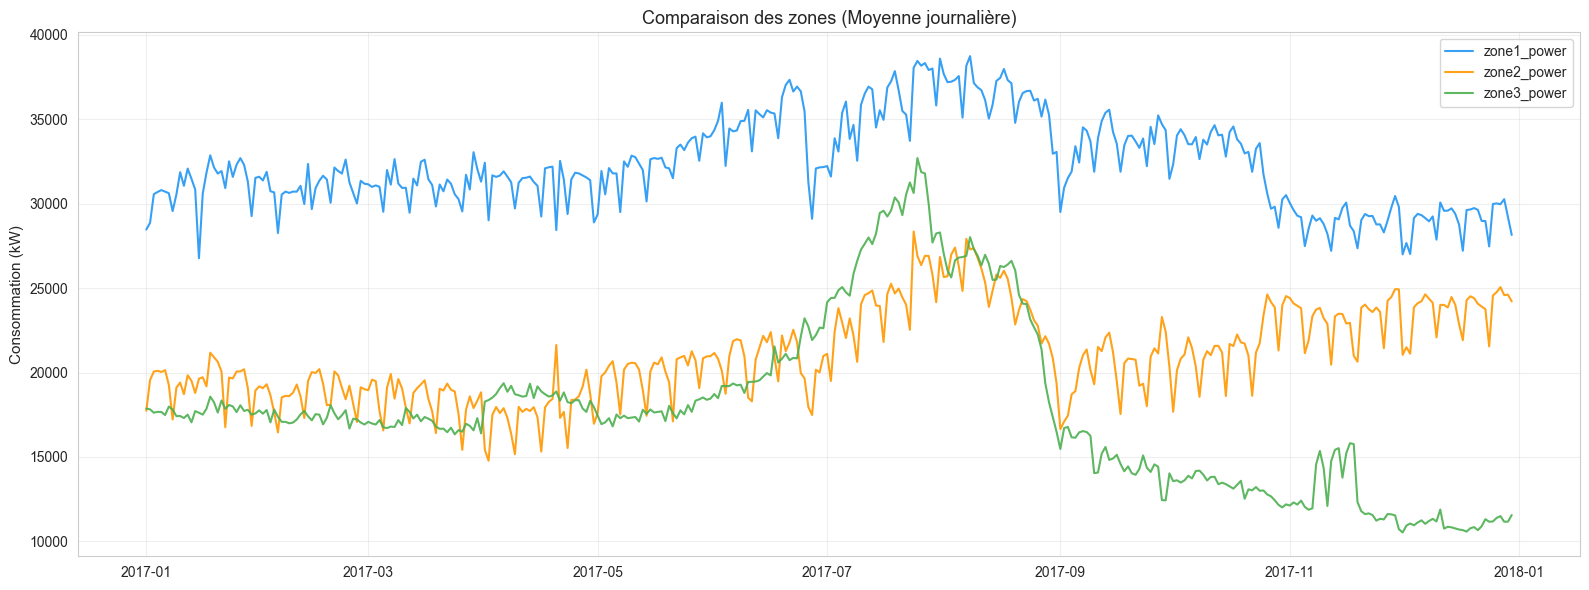

In [10]:
fig, ax = plt.subplots(figsize=(16, 6))
# Agrégation journalière pour plus de lisibilité
df_daily = df[zones].resample('D').mean()

for zone, color in zip(zones, colors):
    ax.plot(df_daily.index, df_daily[zone], color=color, label=zone, linewidth=1.5, alpha=0.9)

ax.set_title("Comparaison des zones (Moyenne journalière)")
ax.set_ylabel("Consommation (kW)")
ax.legend()
plt.tight_layout()
plt.show()

## 9.9 Distribution de la consommation

**Pourquoi :** connaître la forme de la cible.

**Interprétation :** une distribution asymétrique indique des pics rares.

**Impact :** RMSE sera sensible aux pics ; MAPE donnera une lecture relative.

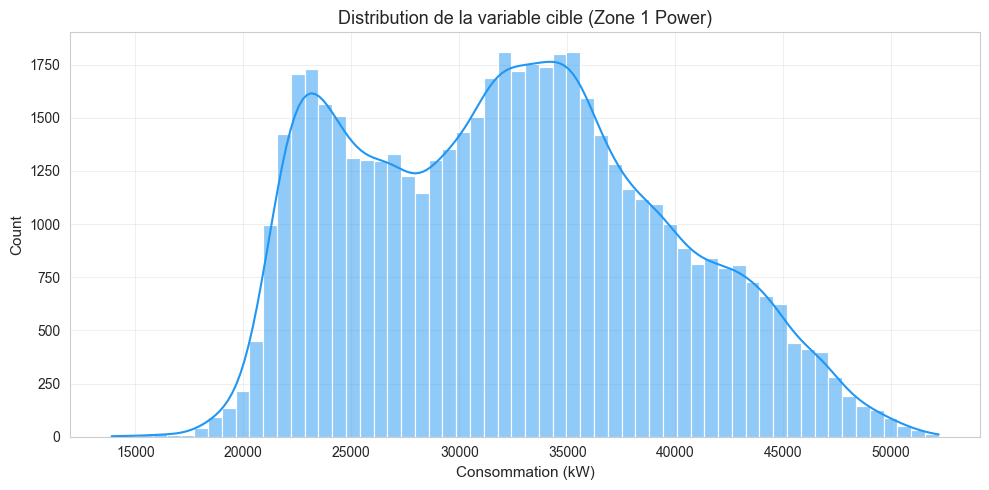

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df["target"], bins=60, kde=True, color="#2196F3", ax=ax)
ax.set_title("Distribution de la variable cible (Zone 1 Power)")
ax.set_xlabel("Consommation (kW)")
plt.tight_layout()
plt.show()

## Rééchantillonnage horaire pour les analyses calendaires et séries temporelles

Afin de mieux visualiser les cycles journaliers et pour la modélisation (SARIMA, etc.), nous allons rééchantillonner les données à une fréquence horaire en utilisant la fonction `resample_hourly` du module `src.preprocessing`.

In [12]:
df_hourly = resample_hourly(df, check_counts=False)
print("Dimensions horaires :", df_hourly.shape)
print("Fréquence horaire inférée :", pd.infer_freq(df_hourly.index))

Dimensions horaires : (8736, 10)
Fréquence horaire inférée : h


## 9.10 Heatmap heure × jour

**Pourquoi :** visualiser les cycles d'activité humaine.

**Interprétation :** les couleurs fortes indiquent les périodes de pointe.

**Impact :** justifie les features `hour`, `dayofweek`, `is_weekend`, `is_peak_hour`.

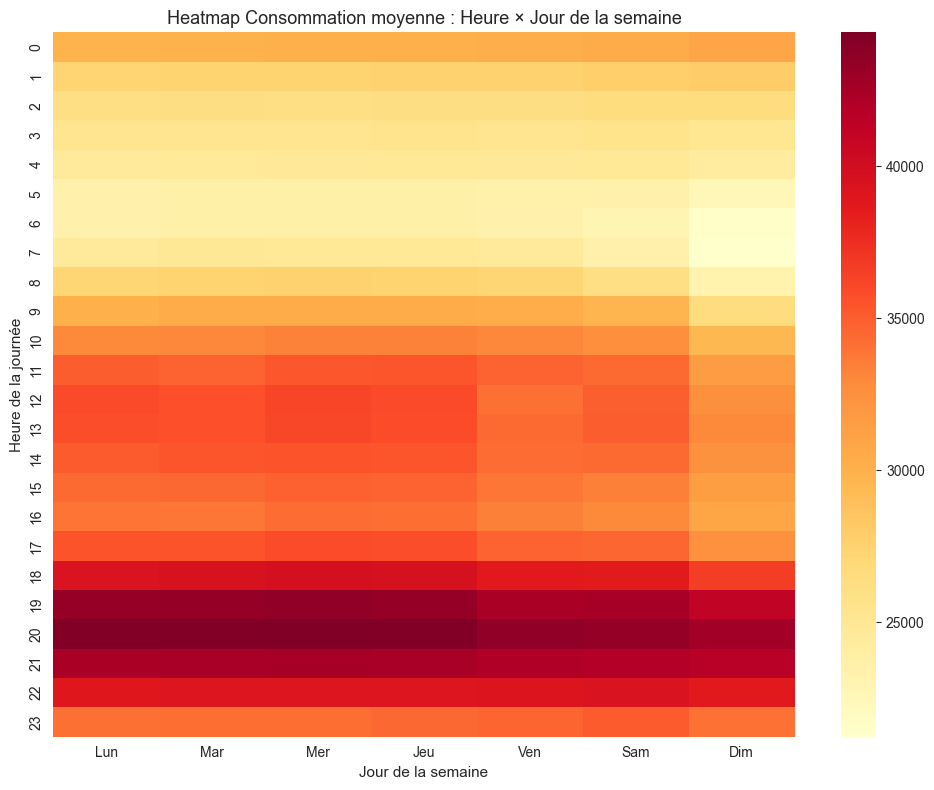

In [13]:
# Création des colonnes hour et dayofweek
df_hourly['hour'] = df_hourly.index.hour
df_hourly['dayofweek'] = df_hourly.index.dayofweek

heatmap_data = df_hourly.pivot_table(index='hour', columns='dayofweek', values='target', aggfunc='mean')
# Jours de 0 (Lundi) à 6 (Dimanche)
heatmap_data.columns = ['Lun', 'Mar', 'Mer', 'Jeu', 'Ven', 'Sam', 'Dim']

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=False, ax=ax)
ax.set_title("Heatmap Consommation moyenne : Heure × Jour de la semaine")
ax.set_ylabel("Heure de la journée")
ax.set_xlabel("Jour de la semaine")
plt.tight_layout()
plt.show()

## 9.11 Consommation moyenne par heure

**Pourquoi :** identifier les heures de pointe journalières.

**Interprétation :** un pic du soir peut refléter l'activité résidentielle ou commerciale.

**Impact :** création des variables heures de pointe et heures creuses.

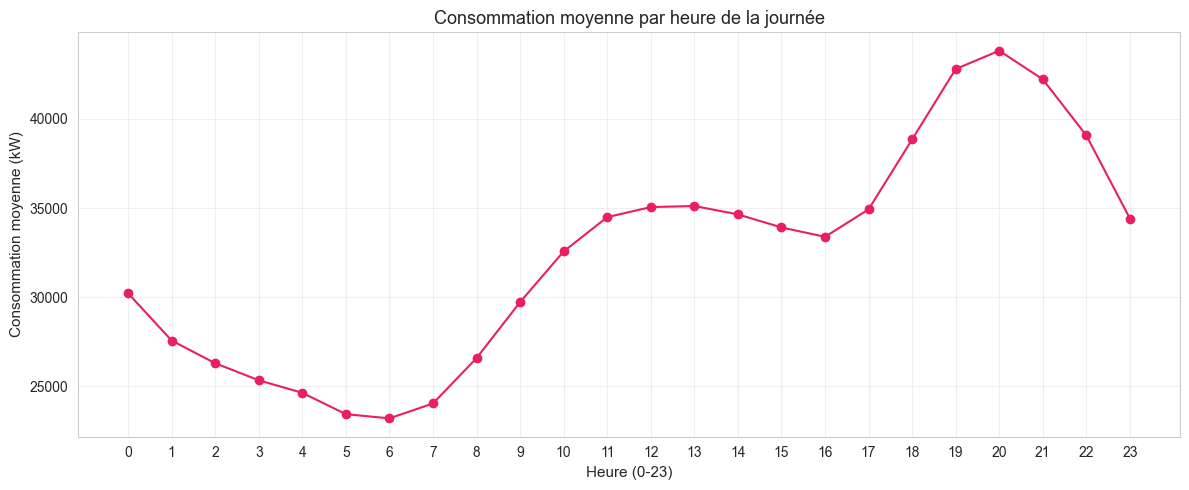

In [14]:
hourly_mean = df_hourly.groupby('hour')['target'].mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(hourly_mean.index, hourly_mean.values, marker='o', linestyle='-', color="#E91E63")
ax.set_title("Consommation moyenne par heure de la journée")
ax.set_xlabel("Heure (0-23)")
ax.set_ylabel("Consommation moyenne (kW)")
ax.set_xticks(range(24))
plt.tight_layout()
plt.show()

## 9.12 Consommation moyenne par jour de semaine

**Pourquoi :** comparer semaine et week-end.

**Interprétation :** les jours ouvrés peuvent avoir une dynamique différente.

**Impact :** création de `is_weekend` et encodage cyclique du jour.

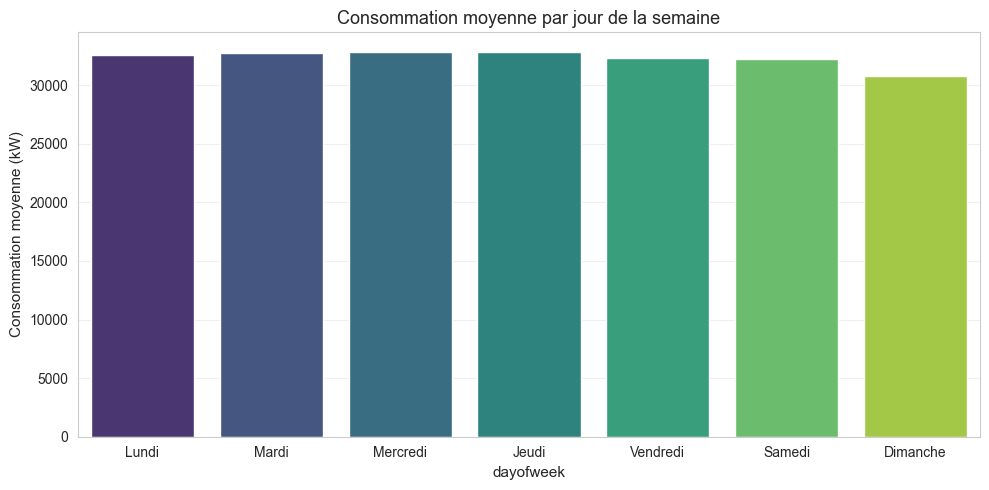

In [15]:
daily_mean = df_hourly.groupby('dayofweek')['target'].mean()
days_labels = ['Lundi', 'Mardi', 'Mercredi', 'Jeudi', 'Vendredi', 'Samedi', 'Dimanche']

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=daily_mean.index, y=daily_mean.values, palette="viridis", ax=ax)
ax.set_title("Consommation moyenne par jour de la semaine")
ax.set_xticklabels(days_labels)
ax.set_ylabel("Consommation moyenne (kW)")
plt.tight_layout()
plt.show()

## 9.13 Consommation moyenne par mois

**Pourquoi :** analyser la saisonnalité annuelle.

**Interprétation :** certains mois peuvent correspondre à une demande plus élevée.

**Impact :** création de `month`, `season`, `HDD`, `CDD`.

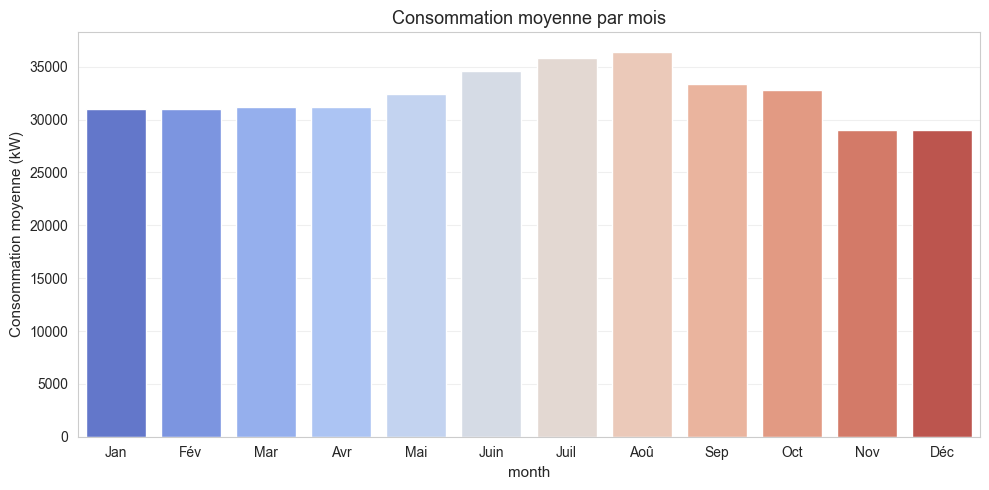

In [16]:
df_hourly['month'] = df_hourly.index.month
monthly_mean = df_hourly.groupby('month')['target'].mean()
months_labels = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Juin', 'Juil', 'Aoû', 'Sep', 'Oct', 'Nov', 'Déc']

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=monthly_mean.index, y=monthly_mean.values, palette="coolwarm", ax=ax)
ax.set_title("Consommation moyenne par mois")
ax.set_xticklabels(months_labels)
ax.set_ylabel("Consommation moyenne (kW)")
plt.tight_layout()
plt.show()

## 9.14 Relation température-consommation

**Pourquoi :** tester l'impact météo.

**Interprétation :** une relation non linéaire peut apparaître selon les besoins de chauffage ou climatisation.

**Impact :** justifie HDD, CDD et interactions météo.

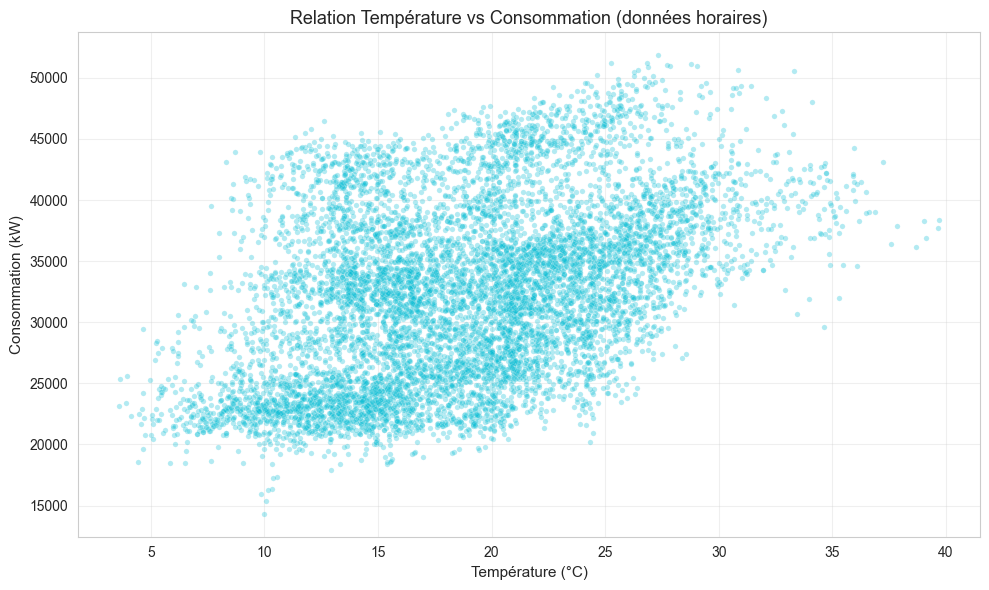

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df_hourly, x="temperature", y="target", alpha=0.3, color="#00BCD4", s=15, ax=ax)
ax.set_title("Relation Température vs Consommation (données horaires)")
ax.set_xlabel("Température (°C)")
ax.set_ylabel("Consommation (kW)")
plt.tight_layout()
plt.show()

## 9.15 Corrélations météo-consommation

**Pourquoi :** mesurer l'association entre météo et charge.

**Interprétation :** température, humidité et flux diffus peuvent influencer la consommation.

**Impact :** les variables météo seront utilisées dans SARIMAX, Prophet et ML.

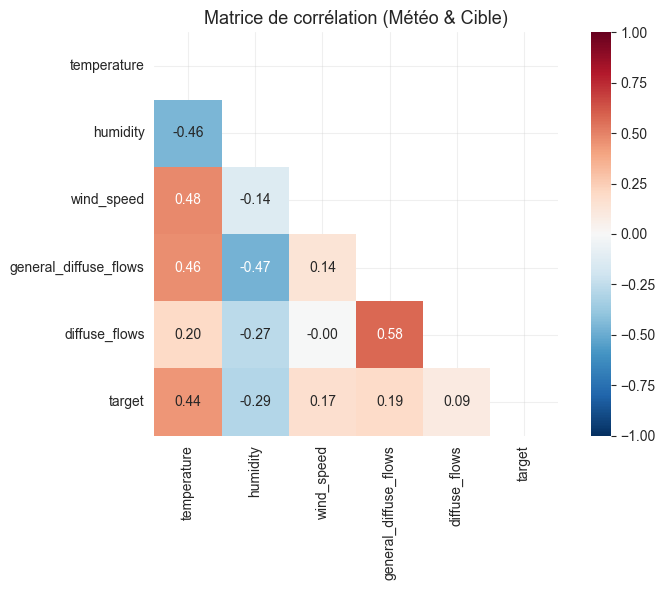

In [19]:
cols_to_corr = ["temperature", "humidity", "wind_speed", "general_diffuse_flows", "diffuse_flows", "target"]
corr_matrix = df_hourly[cols_to_corr].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title("Matrice de corrélation (Météo & Cible)")
plt.tight_layout()
plt.show()

## 9.16 Décomposition STL

**Pourquoi :** séparer tendance, saisonnalité et résidu.

**Interprétation :** une forte saisonnalité montre que la charge suit des cycles.

**Impact :** guide SARIMA/SARIMAX et choix des lags.

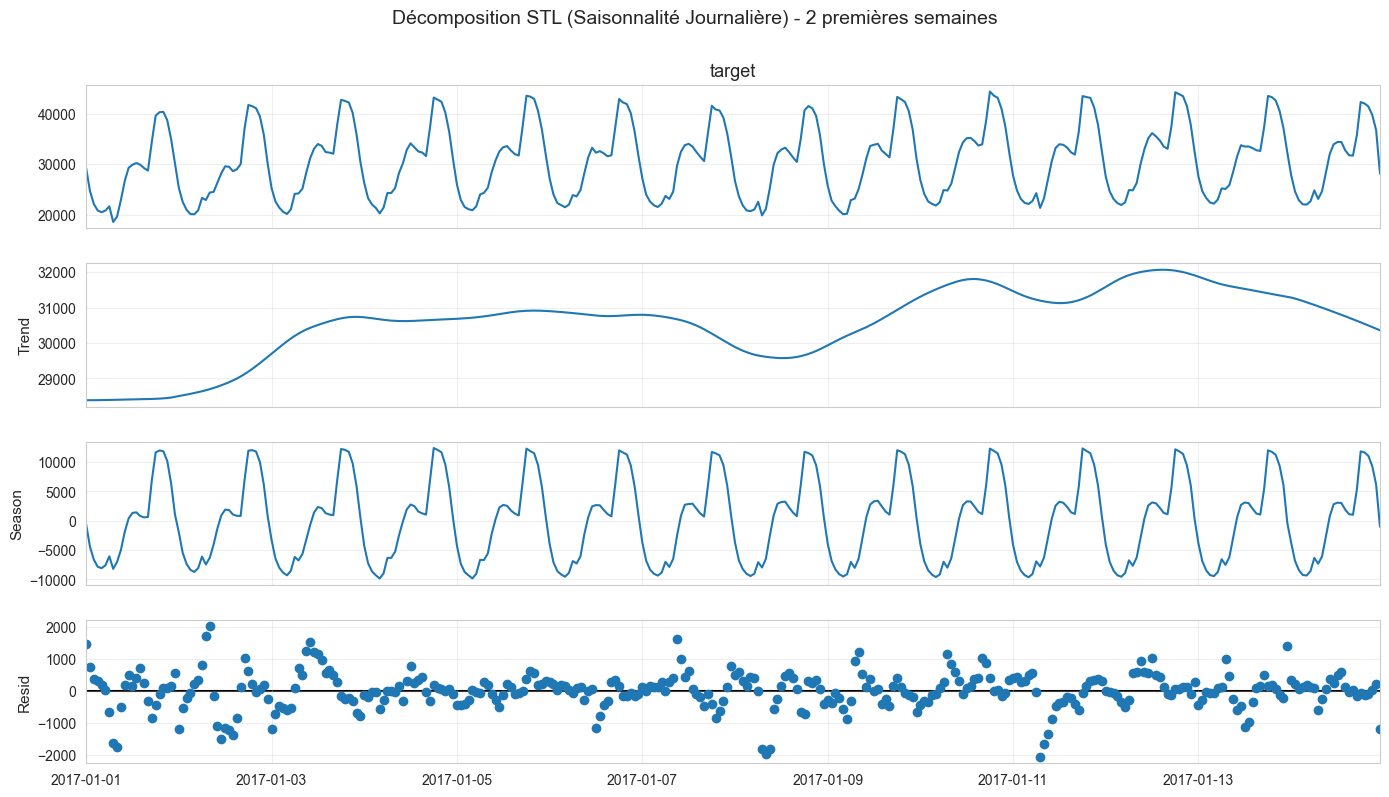

In [20]:
from statsmodels.tsa.seasonal import STL

# On utilise une période de 24 (heures) pour la saisonnalité journalière
# On restreint l'affichage à un sous-ensemble (ex: 2 semaines) pour la lisibilité
df_subset = df_hourly['target'].loc['2017-01-01':'2017-01-14']

stl = STL(df_subset, period=24)
res = stl.fit()

fig = res.plot()
fig.set_size_inches(14, 8)
plt.suptitle("Décomposition STL (Saisonnalité Journalière) - 2 premières semaines", y=1.02, fontsize=14)
plt.show()

## 9.17 ACF / PACF

**Pourquoi :** analyser la mémoire de la série.

**Interprétation :** des pics aux lags 24h ou 168h confirment les cycles journaliers ou hebdomadaires après resampling horaire.

**Impact :** guide la création des lags et les paramètres SARIMA.

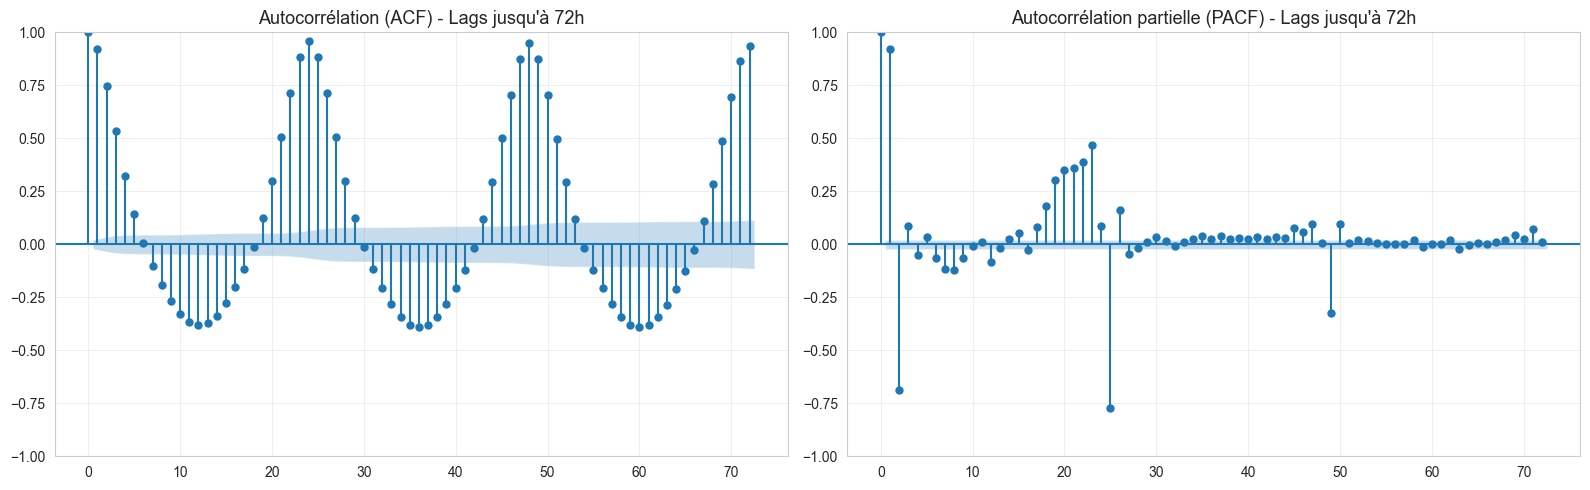

In [21]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(df_hourly['target'], lags=72, ax=axes[0], title="Autocorrélation (ACF) - Lags jusqu'à 72h")
plot_pacf(df_hourly['target'], lags=72, ax=axes[1], title="Autocorrélation partielle (PACF) - Lags jusqu'à 72h")
plt.tight_layout()
plt.show()

## 9.18 Détection des anomalies

**Pourquoi :** repérer les points extrêmes.

**Interprétation :** les anomalies peuvent être techniques ou métier.

**Impact :** les anomalies techniques peuvent être corrigées ; les pics réels doivent être conservés.

Nombre d'anomalies détectées (Z-score > 3.5 sur fenêtre 24h) : 0


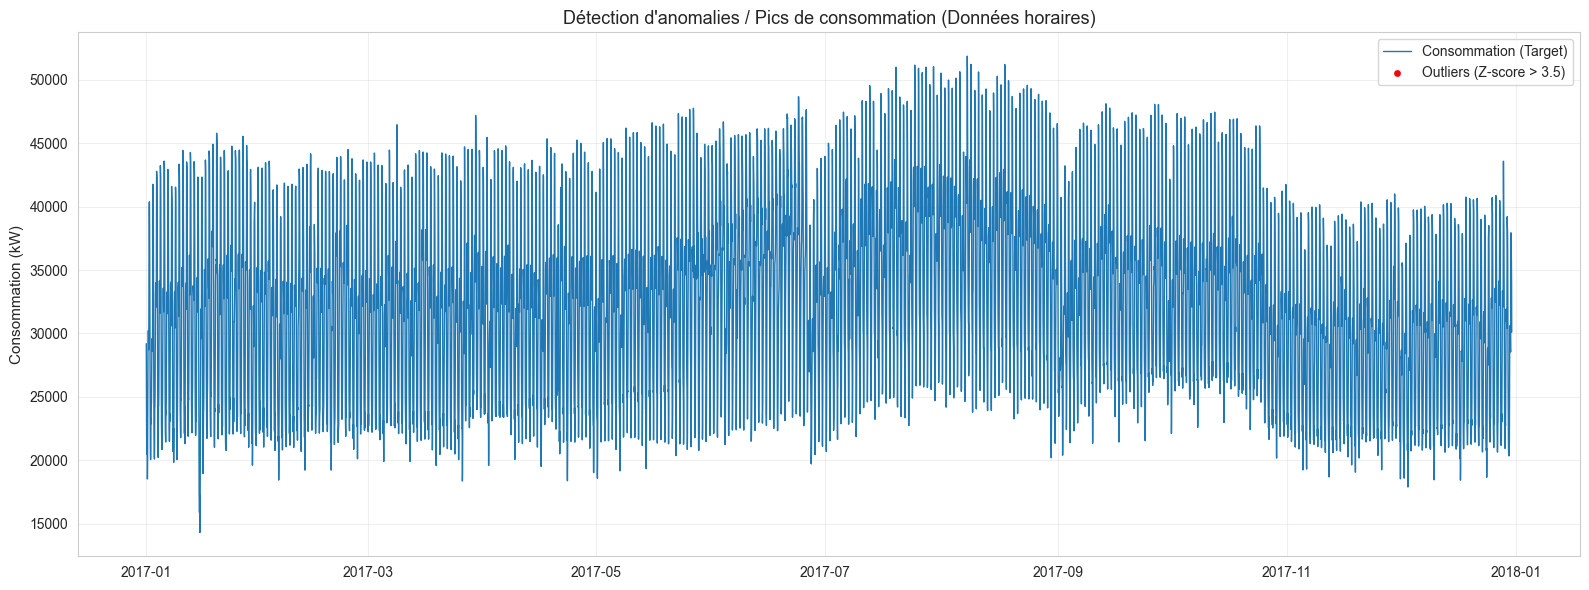

In [22]:
# Utilisation de la fonction du module preprocessing
outlier_mask, zscore = detect_rolling_outliers(df_hourly['target'], window=24, threshold=3.5)

print(f"Nombre d'anomalies détectées (Z-score > 3.5 sur fenêtre 24h) : {outlier_mask.sum()}")

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df_hourly.index, df_hourly['target'], label='Consommation (Target)', color='#1f77b4', linewidth=1)
ax.scatter(df_hourly.index[outlier_mask], df_hourly['target'][outlier_mask], color='red', label='Outliers (Z-score > 3.5)', s=15, zorder=5)

ax.set_title("Détection d'anomalies / Pics de consommation (Données horaires)")
ax.set_ylabel("Consommation (kW)")
ax.legend()
plt.tight_layout()
plt.show()